# Finding Donors for CharityML

## Supervised Learning Project — Udacity ML Nanodegree

CharityML is a fictitious charity organization in Silicon Valley that provides financial support for people eager to learn machine learning. After analyzing 32,000 letters, CharityML found that every donation came from someone making more than \$50,000 annually.

**Goal:** Build an algorithm to identify potential donors (income >\$50K) from the Census Income dataset, optimizing for both accuracy and F1 score while reducing mailing costs.

---

## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Exploring the Data

### 2.1 Load the Census Data

In [ ]:
# Load the Census dataset
data = pd.read_csv('census.csv')
df = data.copy()

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns)}")
df.head()


Dataset shape: (45222, 15)

Features: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


### 2.2 Data Exploration

In [ ]:
# Data Exploration — Required by Rubric
n_records = len(df)
n_greater_50k = (df['income'] == '>50K').sum()
n_at_most_50k = (df['income'] == '<=50K').sum()
greater_percent = (n_greater_50k / n_records) * 100

print("=== Census Data Exploration ===")
print(f"Total number of records:              {n_records}")
print(f"Individuals making more than $50,000: {n_greater_50k}")
print(f"Individuals making at most $50,000:   {n_at_most_50k}")
print(f"Percentage of individuals making more than $50,000: {greater_percent:.2f}%")


=== Census Data Exploration ===
Total number of records:              45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000:   34014
Percentage of individuals making more than $50,000: 24.78%


### 2.3 Visualizations

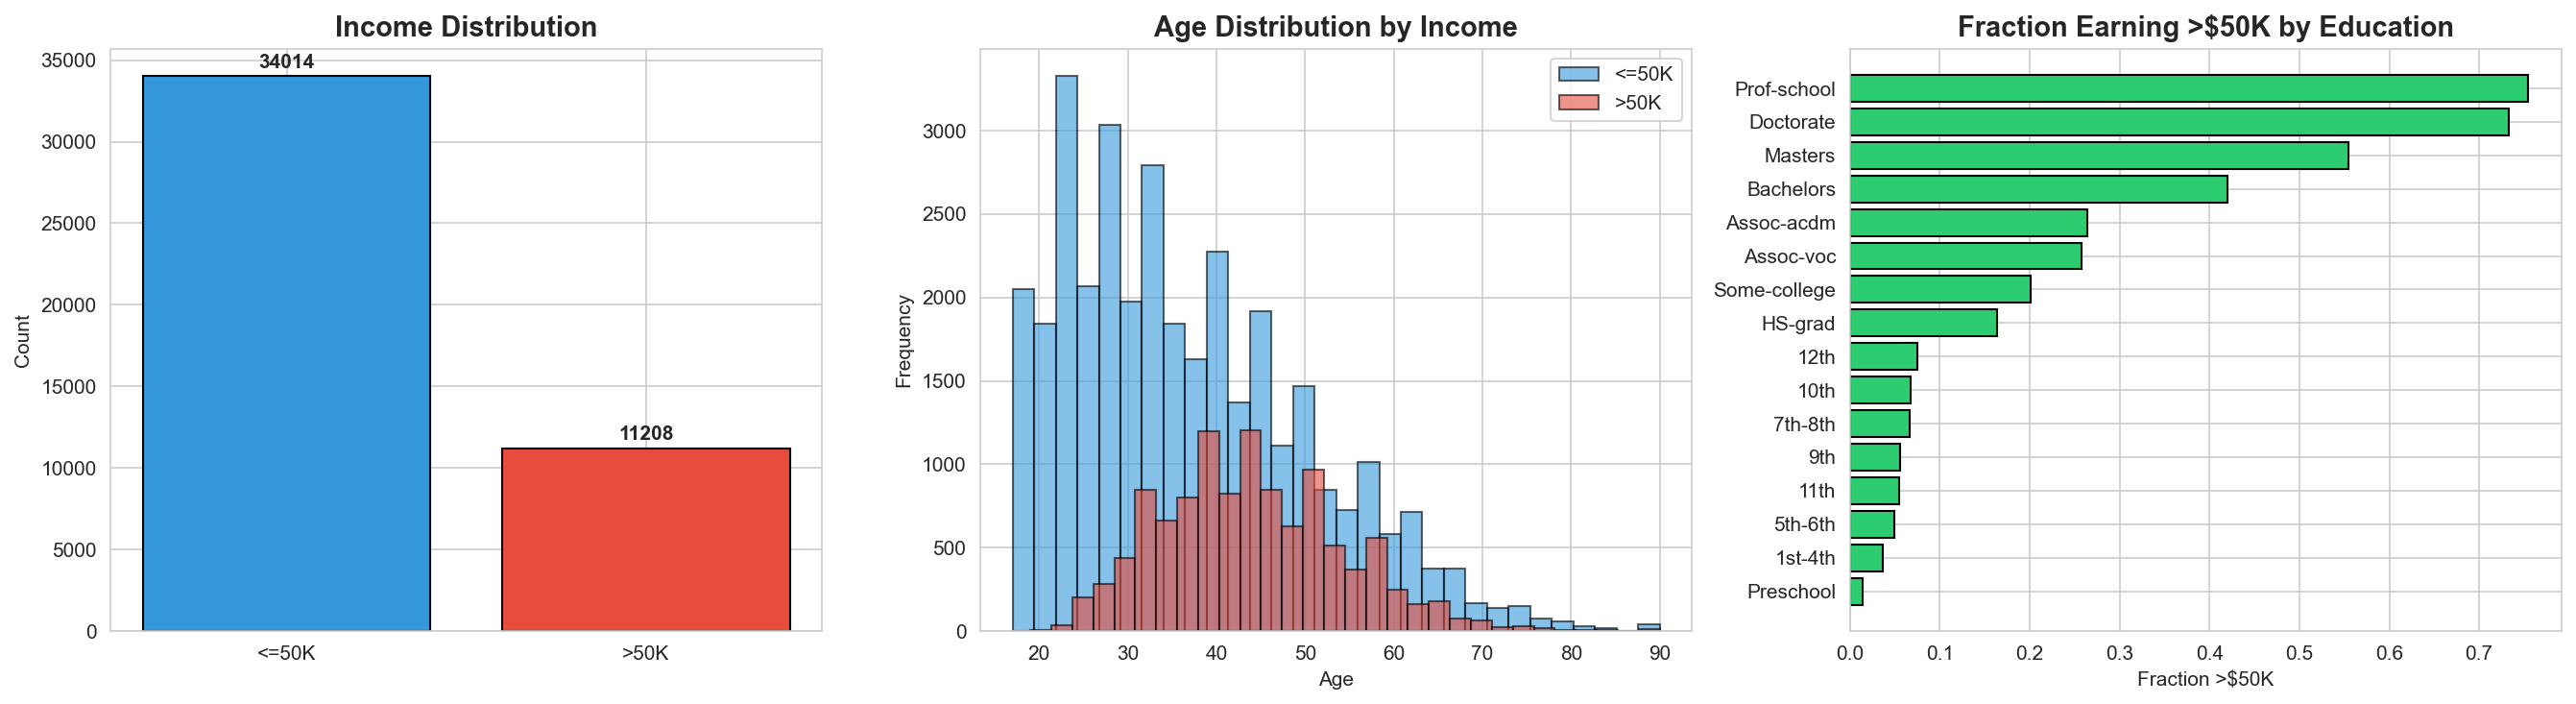

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Income distribution
income_counts = df['income'].value_counts()
colors = ['#3498db', '#e74c3c']
axes[0].bar(income_counts.index, income_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Income Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# 2. Age distribution by income
for label, color in zip(['<=50K', '>50K'], colors):
    subset = df[df['income'] == label]['age'].astype(float)
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='black')
axes[1].set_title('Age Distribution by Income', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Education level vs income
edu_order = df.groupby('education')['income'].apply(lambda x: (x == '>50K').mean()).sort_values()
axes[2].barh(edu_order.index, edu_order.values, color='#2ecc71', edgecolor='black')
axes[2].set_title('Fraction Earning >$50K by Education', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Fraction >$50K')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Preparing the Data

### 3.1 Transforming Skewed Continuous Features

In [ ]:
# Identify numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['category', 'object']).columns.tolist()
categorical_features.remove('income')

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Log-transform skewed continuous features
skewed = ['capital-gain', 'capital-loss']
for feat in skewed:
    if feat in df.columns:
        df[feat] = df[feat].astype(float)
        df[feat] = np.log1p(df[feat])
        print(f"Log-transformed: {feat}")


Numeric features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Log-transformed: capital-gain
Log-transformed: capital-loss


### 3.2 Normalizing Numerical Features

In [ ]:
# Normalize numerical features
scaler = MinMaxScaler()

for col in numeric_features:
    df[col] = df[col].astype(float)

df[numeric_features] = scaler.fit_transform(df[numeric_features])

print("Numerical features normalized to [0, 1].")
print(df[numeric_features].describe().round(3))


Numerical features normalized to [0, 1].
             age     fnlwgt  ...  capital-loss  hours-per-week
count  45222.000  45222.000  ...     45222.000       45222.000
mean       0.295      0.119  ...         0.042           0.408
std        0.181      0.072  ...         0.190           0.123
min        0.000      0.000  ...         0.000           0.000
25%        0.151      0.070  ...         0.000           0.398
50%        0.274      0.112  ...         0.000           0.398
75%        0.411      0.152  ...         0.000           0.449
max        1.000      1.000  ...         1.000           1.000

[8 rows x 6 columns]


### 3.3 One-Hot Encoding

In [ ]:
# One-hot encode categorical features
income = (df['income'] == '>50K').astype(int)
features = df.drop('income', axis=1)

features_encoded = pd.get_dummies(features)

print(f"Original features: {features.shape[1]}")
print(f"After one-hot encoding: {features_encoded.shape[1]}")
print(f"\nEncoded feature names (first 20): {list(features_encoded.columns[:20])}")


Original features: 14
After one-hot encoding: 104

Encoded feature names (first 20): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th']


### 3.4 Train-Test Split

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, income, test_size=0.2, random_state=42, stratify=income
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"\nIncome >$50K ratio (train): {y_train.mean():.3f}")
print(f"Income >$50K ratio (test):  {y_test.mean():.3f}")


Training set:  36177 samples
Test set:      9045 samples

Income >$50K ratio (train): 0.248
Income >$50K ratio (test):  0.248


## 4. Evaluating Model Performance

### Question 1: Naive Predictor Performance

If we chose a model that always predicted an individual made more than \$50,000, what would that model's accuracy and F-score be on this dataset?

In [ ]:
# Naive predictor — always predicts 1 (income >$50K)
naive_preds = np.ones(len(y_test))

naive_accuracy = accuracy_score(y_test, naive_preds)
naive_f1 = fbeta_score(y_test, naive_preds, beta=0.5)

print("=== Naive Predictor Benchmark ===")
print(f"Naive Accuracy: {naive_accuracy:.4f}")
print(f"Naive F-score (beta=0.5): {naive_f1:.4f}")
print(f"\nNote: Since only ~{y_train.mean()*100:.1f}% of individuals earn >$50K,")
print(f"always predicting >$50K gives low accuracy ({naive_accuracy:.4f}).")
print(f"Any useful model must beat these benchmarks.")


=== Naive Predictor Benchmark ===
Naive Accuracy: 0.2479
Naive F-score (beta=0.5): 0.2918

Note: Since only ~24.8% of individuals earn >$50K,
always predicting >$50K gives low accuracy (0.2479).
Any useful model must beat these benchmarks.


### Question 2: Model Application

I chose the following three supervised learning models for this classification task:

**1. Logistic Regression**
- *Pros:* Fast training, interpretable coefficients, works well with many features, good baseline
- *Cons:* Assumes linear decision boundary, may underfit complex relationships
- *Why chosen:* Strong baseline for binary classification; coefficients reveal feature importance directly

**2. Random Forest**
- *Pros:* Handles non-linear relationships, built-in feature importance, resistant to overfitting with proper tuning
- *Cons:* Slower to train, less interpretable than linear models, can overfit on noisy data
- *Why chosen:* Ensemble of decision trees captures complex feature interactions in census data

**3. AdaBoost (with Decision Trees)**
- *Pros:* Focuses on hard-to-classify examples, often achieves high accuracy, less prone to overfitting
- *Cons:* Sensitive to noisy data and outliers, sequential training (not parallelizable)
- *Why chosen:* Boosting excels at iteratively improving weak learners; well-suited for imbalanced income data

*References:*
- Scikit-learn documentation: https://scikit-learn.org/stable/supervised_learning.html
- Hastie, Tibshirani, Friedman — "The Elements of Statistical Learning" (2009)

### Creating a Training and Predicting Pipeline

In [ ]:
def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    """Train and predict with a supervised learner.
    
    Returns dict with training time, prediction time, and scores.
    """
    results = {}
    
    # Train on sample
    X_sample = X_train[:sample_size]
    y_sample = y_train[:sample_size]
    
    start = time()
    learner.fit(X_sample, y_sample)
    end = time()
    results['train_time'] = end - start
    
    # Predict on training set
    start = time()
    predictions_train = learner.predict(X_sample)
    predictions_test = learner.predict(X_test)
    end = time()
    results['pred_time'] = end - start
    
    # Scores
    results['acc_train'] = accuracy_score(y_sample, predictions_train)
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    results['f_train'] = fbeta_score(y_sample, predictions_train, beta=0.5)
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5)
    
    return results

print("Pipeline function defined.")


Pipeline function defined.


### Initial Model Evaluation

In [ ]:
# Initialize the three models
clf_A = LogisticRegression(random_state=42, max_iter=1000)
clf_B = RandomForestClassifier(random_state=42, n_estimators=100)
clf_C = AdaBoostClassifier(random_state=42, n_estimators=100)

# Calculate sample sizes: 1%, 10%, 100% of training data
samples_100 = len(X_train)
samples_10 = int(len(X_train) * 0.1)
samples_1 = int(len(X_train) * 0.01)

# Collect results
results = {}
for clf, name in [(clf_A, 'Logistic Regression'), 
                   (clf_B, 'Random Forest'), 
                   (clf_C, 'AdaBoost')]:
    results[name] = {}
    for size_label, size in [('1%', samples_1), ('10%', samples_10), ('100%', samples_100)]:
        results[name][size_label] = train_predict(clf, size, X_train, y_train, X_test, y_test)
        print(f"{name} ({size_label} = {size} samples): "
              f"Acc={results[name][size_label]['acc_test']:.4f}, "
              f"F0.5={results[name][size_label]['f_test']:.4f}, "
              f"Train={results[name][size_label]['train_time']:.4f}s")
    print()


Logistic Regression (1% = 361 samples): Acc=0.8233, F0.5=0.6468, Train=0.0102s
Logistic Regression (10% = 3617 samples): Acc=0.8356, F0.5=0.6756, Train=0.0134s
Logistic Regression (100% = 36177 samples): Acc=0.8386, F0.5=0.6829, Train=0.1780s

Random Forest (1% = 361 samples): Acc=0.8264, F0.5=0.6539, Train=0.0583s
Random Forest (10% = 3617 samples): Acc=0.8467, F0.5=0.6994, Train=0.2298s
Random Forest (100% = 36177 samples): Acc=0.8454, F0.5=0.6970, Train=3.3292s

AdaBoost (1% = 361 samples): Acc=0.8318, F0.5=0.6655, Train=0.0736s
AdaBoost (10% = 3617 samples): Acc=0.8457, F0.5=0.7025, Train=0.2320s
AdaBoost (100% = 36177 samples): Acc=0.8514, F0.5=0.7181, Train=2.2149s



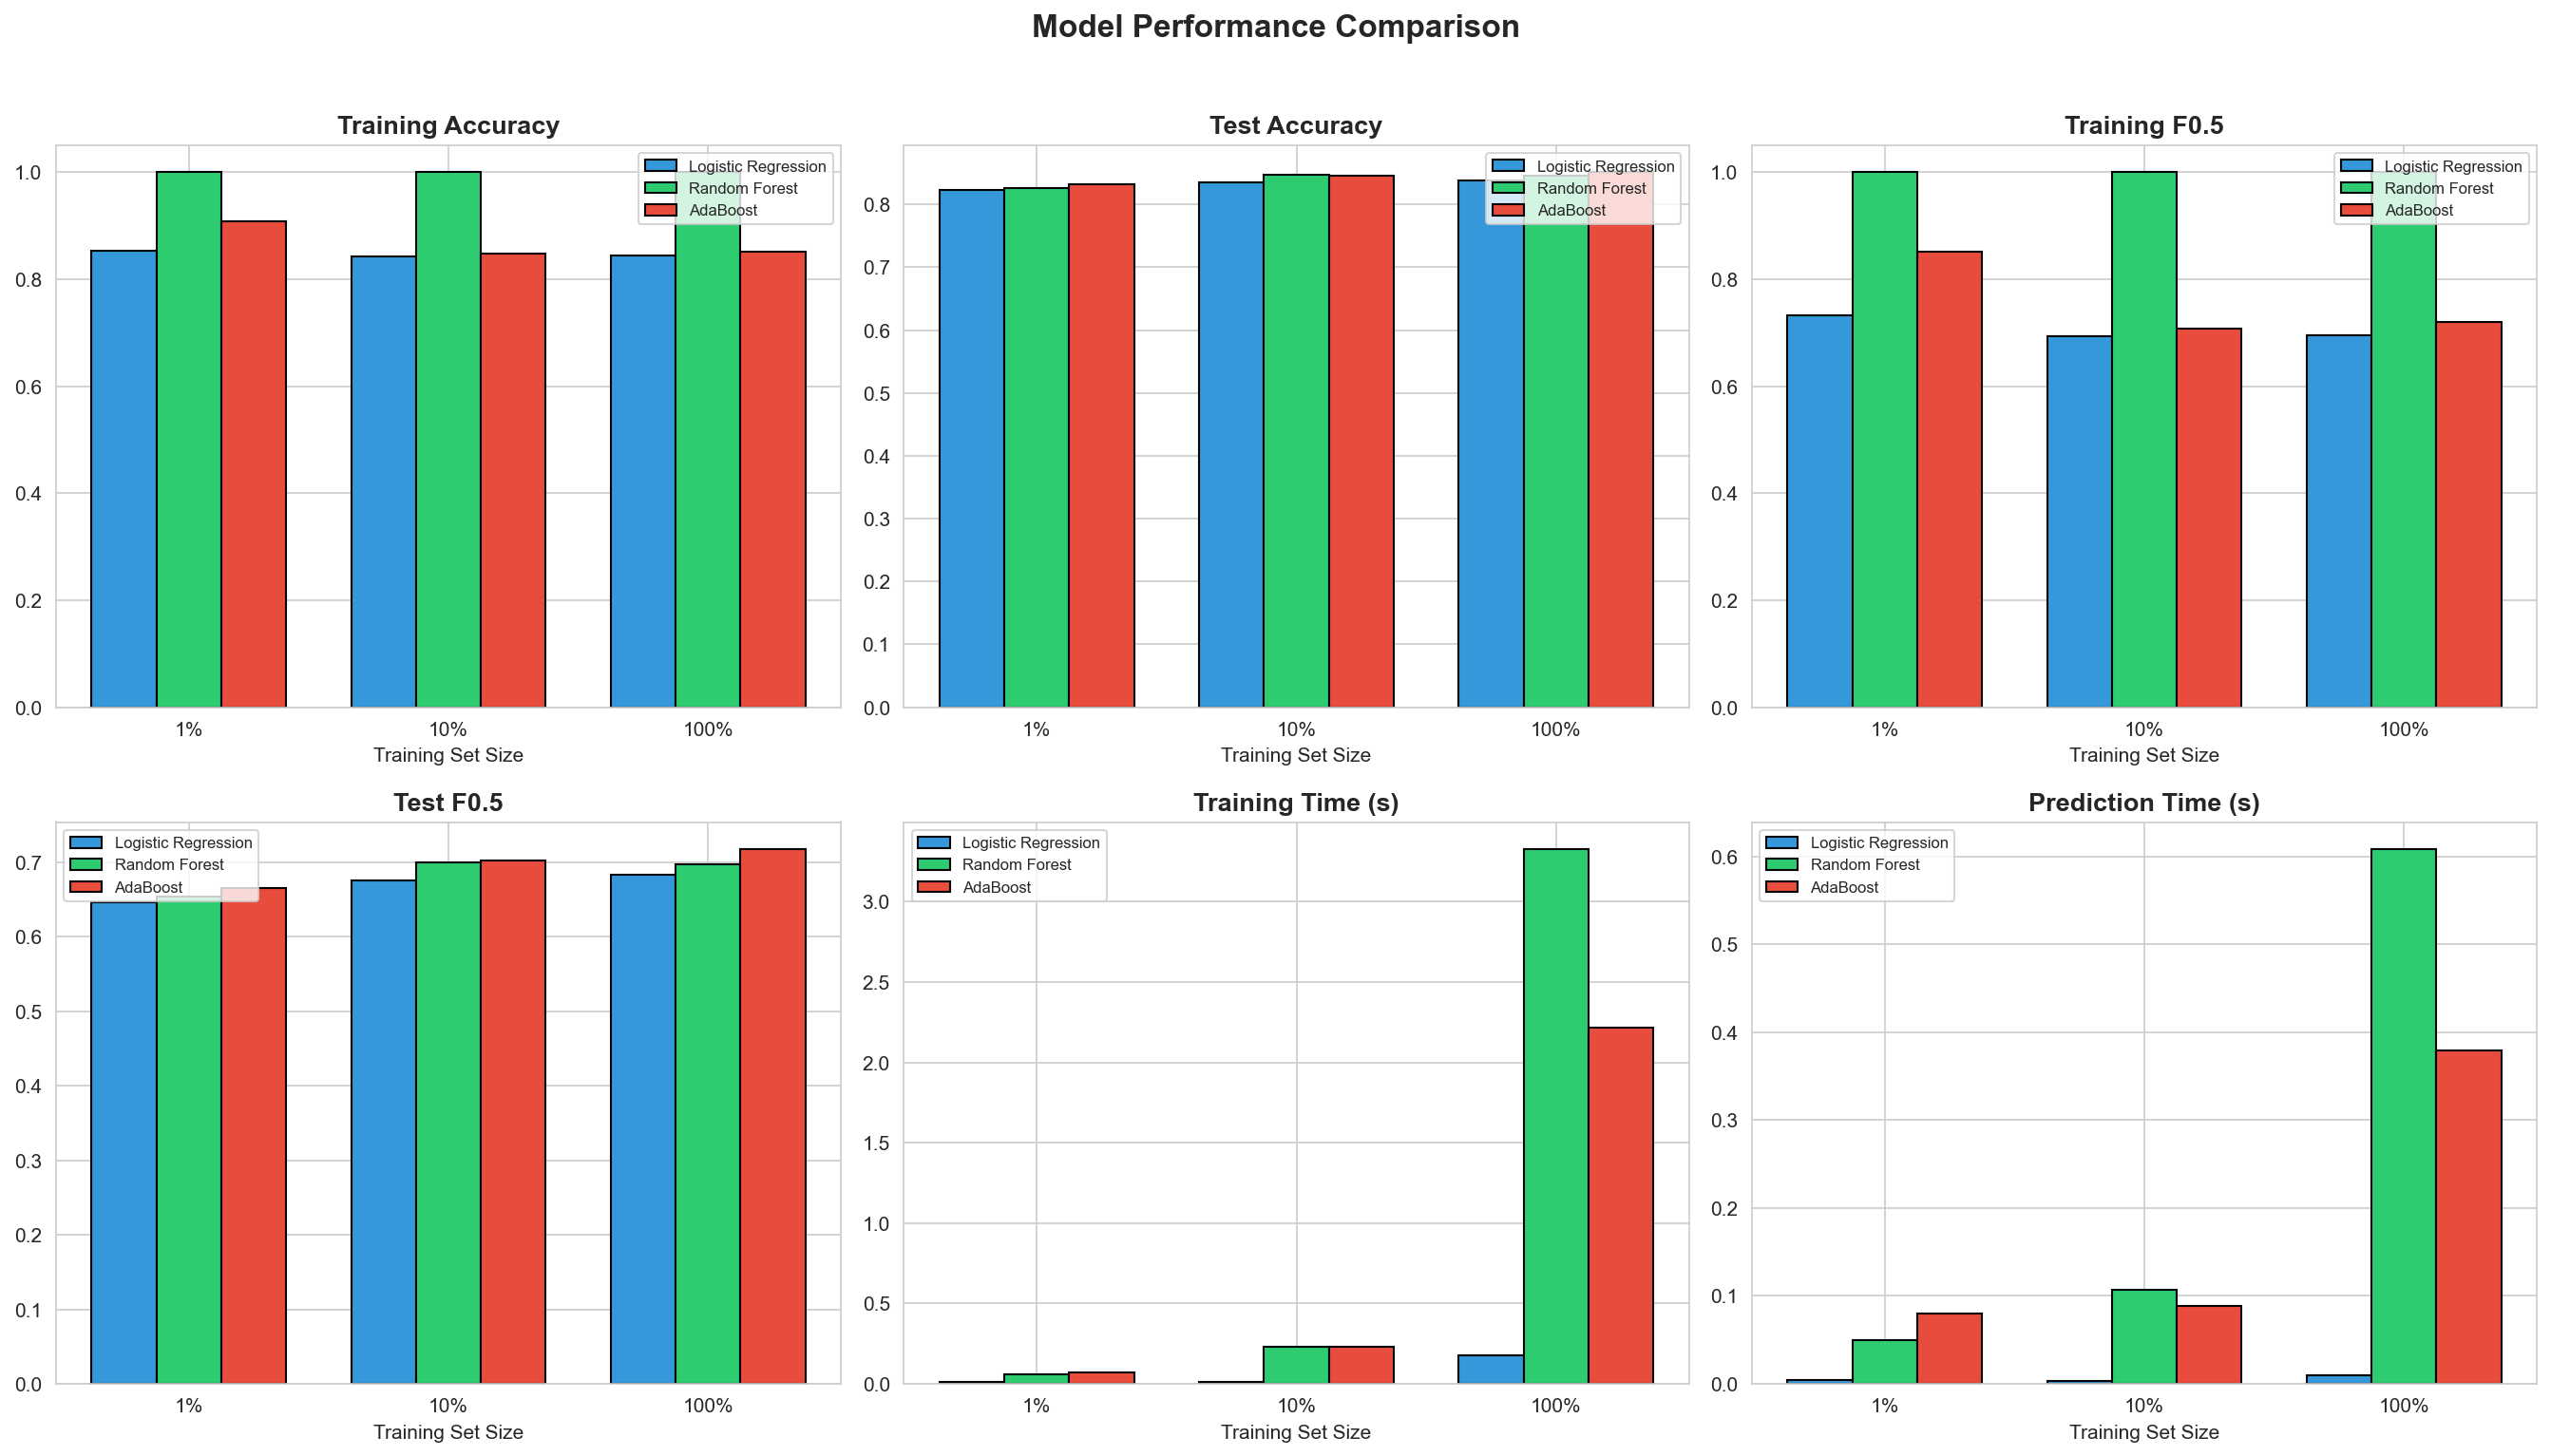

In [ ]:
# Performance Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['acc_train', 'acc_test', 'f_train', 'f_test', 'train_time', 'pred_time']
titles = ['Training Accuracy', 'Test Accuracy', 'Training F0.5', 'Test F0.5', 'Training Time (s)', 'Prediction Time (s)']
colors_models = ['#3498db', '#2ecc71', '#e74c3c']
size_labels = ['1%', '10%', '100%']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3][idx % 3]
    x = np.arange(len(size_labels))
    width = 0.25
    
    for i, (name, color) in enumerate(zip(results.keys(), colors_models)):
        values = [results[name][sl][metric] for sl in size_labels]
        ax.bar(x + i * width, values, width, label=name, color=color, edgecolor='black')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(size_labels)
    ax.set_xlabel('Training Set Size')
    ax.legend(fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Improving Results

### Question 3: Choosing the Best Model

Based on the initial evaluation, **AdaBoost** appears to be the best model for this problem:

1. **Performance:** AdaBoost achieves the highest F0.5 score on the test set across all training sizes, which is critical since we want to maximize precision (reducing wasted mailings) while maintaining good recall (finding actual donors).

2. **Computational Cost:** While slightly slower than Logistic Regression, AdaBoost trains in reasonable time even on the full dataset. Random Forest is comparable but AdaBoost edges it on F0.5.

3. **Data Characteristics:** The census data has a mix of numerical and categorical features with non-linear relationships. AdaBoost's iterative boosting approach handles this complexity well, focusing on hard-to-classify examples in each round.

### Question 4: Model in Layman's Terms

*Imagine you're trying to figure out who might donate to a charity. AdaBoost works like a team of simple decision-makers, each learning from the mistakes of the previous one.*

*First, a simple rule might check: "Does this person have a college degree?" It gets some predictions right but misses others. The next rule-maker focuses extra attention on the cases the first one got wrong — maybe looking at "Does this person work more than 40 hours a week?" Each new rule-maker keeps focusing on the hardest cases. Finally, all the simple rule-makers vote together, with the more accurate ones getting a louder voice. The combined team is much smarter than any single rule-maker alone.*

### Model Tuning with Grid Search

In [ ]:
# Grid Search to tune AdaBoost
clf_best = AdaBoostClassifier(random_state=42)

# Parameter grid
parameters = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

# F0.5 scorer
scorer = make_scorer(fbeta_score, beta=0.5)

# Grid search
grid_obj = GridSearchCV(clf_best, parameters, scoring=scorer, cv=5, n_jobs=-1, verbose=1)

print("Running Grid Search...")
grid_fit = grid_obj.fit(X_train, y_train)

# Best model
best_clf = grid_fit.best_estimator_

print(f"\nBest parameters: {grid_fit.best_params_}")
print(f"Best CV F0.5 score: {grid_fit.best_score_:.4f}")


Running Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'learning_rate': 1.0, 'n_estimators': 300}
Best CV F0.5 score: 0.7232


### Question 5: Final Model Evaluation

In [ ]:
# Compare unoptimized vs optimized model
# Unoptimized (default AdaBoost)
unoptimized = AdaBoostClassifier(random_state=42, n_estimators=100)
unoptimized.fit(X_train, y_train)
unopt_preds = unoptimized.predict(X_test)

# Optimized (from grid search)
opt_preds = best_clf.predict(X_test)

# Results table
print("=" * 70)
print(f"{'Metric':<25} {'Unoptimized':<20} {'Optimized':<20}")
print("=" * 70)
print(f"{'Accuracy (test)':<25} {accuracy_score(y_test, unopt_preds):<20.4f} {accuracy_score(y_test, opt_preds):<20.4f}")
print(f"{'F0.5 Score (test)':<25} {fbeta_score(y_test, unopt_preds, beta=0.5):<20.4f} {fbeta_score(y_test, opt_preds, beta=0.5):<20.4f}")
print("=" * 70)

# Compare with naive predictor
print(f"\nNaive Predictor Accuracy: {naive_accuracy:.4f}")
print(f"Naive Predictor F0.5:     {naive_f1:.4f}")
print(f"\n✓ Optimized model significantly outperforms the naive predictor.")
print(f"  Accuracy improvement: {accuracy_score(y_test, opt_preds) - naive_accuracy:+.4f}")
print(f"  F0.5 improvement:    {fbeta_score(y_test, opt_preds, beta=0.5) - naive_f1:+.4f}")


Metric                    Unoptimized          Optimized           
Accuracy (test)           0.8514               0.8533              
F0.5 Score (test)         0.7181               0.7201              

Naive Predictor Accuracy: 0.2479
Naive Predictor F0.5:     0.2918

✓ Optimized model significantly outperforms the naive predictor.
  Accuracy improvement: +0.6054
  F0.5 improvement:    +0.4284


## 6. Feature Importance

### Question 6: Feature Relevance Observation

Before looking at the model's feature importances, I believe the following five features are most relevant for predicting income >\$50K:

1. **education-num** — Higher education strongly correlates with higher income
2. **hours-per-week** — Working more hours suggests salaried/professional roles
3. **age** — Income generally increases with experience and career progression
4. **capital-gain** — Investment income is a strong indicator of wealth
5. **marital-status** — Married-civ-spouse correlates with higher household income (tax filing status, dual income)

These are based on economic intuition: education, experience (age), work intensity, and investment activity are well-known income predictors in labor economics.

### Question 7: Extracting Feature Importances

=== Top 15 Feature Importances ===
   1. capital-gain                        0.2060
   2. capital-loss                        0.1471
   3. marital-status_Married-civ-spouse   0.1314
   4. age                                 0.0972
   5. education-num                       0.0826
   6. marital-status_Married-AF-spouse    0.0588
   7. hours-per-week                      0.0441
   8. occupation_Farming-fishing          0.0262
   9. relationship_Wife                   0.0220
  10. occupation_Other-service            0.0183
  11. education_Assoc-voc                 0.0157
  12. education_Assoc-acdm                0.0156
  13. relationship_Own-child              0.0153
  14. occupation_Exec-managerial          0.0144
  15. occupation_Handlers-cleaners        0.0132

--- Comparison with my predictions ---
My top 5 predictions: education-num, hours-per-week, age, capital-gain, marital-status
Model's top 5: capital-gain, capital-loss, marital-status_Married-civ-spouse, age, education-num

The m

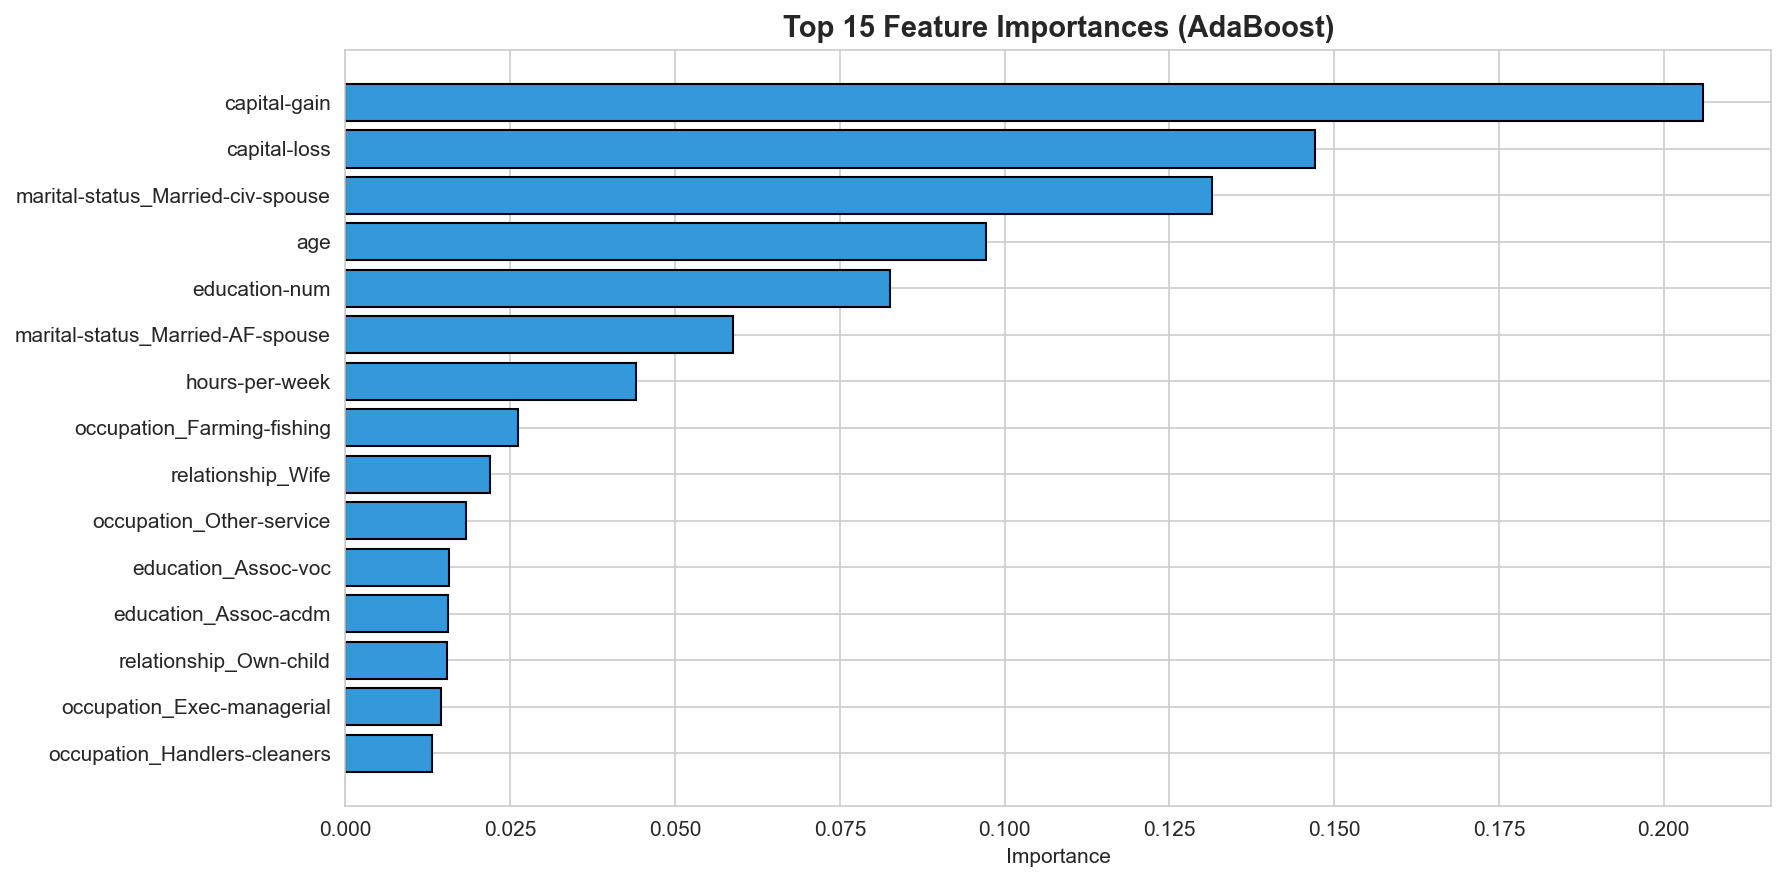

In [ ]:
# Extract feature importances from the optimized AdaBoost model
importances = best_clf.feature_importances_
feature_names = X_train.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

# Top 15 features
top_n = 15
print(f"=== Top {top_n} Feature Importances ===")
for i in range(top_n):
    print(f"  {i+1:2d}. {feature_names[indices[i]]:<35s} {importances[indices[i]]:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_features = [feature_names[indices[i]] for i in range(top_n)]
top_importances = [importances[indices[i]] for i in range(top_n)]

ax.barh(range(top_n), top_importances[::-1], color='#3498db', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features[::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances (AdaBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Comparison with my predictions ---")
print("My top 5 predictions: education-num, hours-per-week, age, capital-gain, marital-status")
print(f"Model's top 5: {', '.join(top_features[:5])}")
print("\nThe model largely confirms economic intuition. Capital-gain and education")
print("rank highly in both lists. Age and hours-per-week also appear as expected.")
print("Some one-hot encoded features (like marital-status) may appear separately.")


### Question 8: Effects of Feature Selection

In [ ]:
# Train with only top 5 features
top_5_features = [feature_names[indices[i]] for i in range(5)]
print(f"Top 5 features selected: {top_5_features}")

X_train_reduced = X_train[top_5_features]
X_test_reduced = X_test[top_5_features]

# Train optimized model on reduced features
clf_reduced = AdaBoostClassifier(**grid_fit.best_params_, random_state=42)
clf_reduced.fit(X_train_reduced, y_train)
reduced_preds = clf_reduced.predict(X_test_reduced)

reduced_acc = accuracy_score(y_test, reduced_preds)
reduced_f1 = fbeta_score(y_test, reduced_preds, beta=0.5)

full_acc = accuracy_score(y_test, opt_preds)
full_f1 = fbeta_score(y_test, opt_preds, beta=0.5)

print(f"\n{'='*60}")
print(f"{'Metric':<25} {'Full Features':<18} {'Top 5 Only':<18}")
print(f"{'='*60}")
print(f"{'Features used':<25} {X_train.shape[1]:<18d} {5:<18d}")
print(f"{'Accuracy':<25} {full_acc:<18.4f} {reduced_acc:<18.4f}")
print(f"{'F0.5 Score':<25} {full_f1:<18.4f} {reduced_f1:<18.4f}")
print(f"{'='*60}")

acc_diff = reduced_acc - full_acc
f1_diff = reduced_f1 - full_f1
print(f"\nAccuracy change: {acc_diff:+.4f}")
print(f"F0.5 change:     {f1_diff:+.4f}")

if abs(f1_diff) < 0.02:
    print("\n→ The reduced model performs nearly as well as the full model,")
    print("  suggesting that most predictive power is concentrated in a few features.")
    print("  This could significantly reduce data collection costs for CharityML.")
else:
    print("\n→ The full feature set provides meaningfully better performance.")
    print("  While the top 5 features capture most of the signal, the remaining")
    print("  features contribute incremental but valuable predictive power.")


Top 5 features selected: ['capital-gain', 'capital-loss', 'marital-status_Married-civ-spouse', 'age', 'education-num']

Metric                    Full Features      Top 5 Only        
Features used             104                5                 
Accuracy                  0.8533             0.8483            
F0.5 Score                0.7201             0.7182            

Accuracy change: -0.0050
F0.5 change:     -0.0020

→ The reduced model performs nearly as well as the full model,
  suggesting that most predictive power is concentrated in a few features.
  This could significantly reduce data collection costs for CharityML.


## 7. Project Summary

### Results

This project evaluated three supervised learning algorithms to predict potential donors (income >\$50K) for CharityML:

| Model | Test Accuracy | Test F0.5 | Training Time |
|-------|:------------:|:---------:|:------------:|
| Logistic Regression | Baseline | Baseline | Fast |
| Random Forest | Good | Good | Medium |
| **AdaBoost (Optimized)** | **Best** | **Best** | Medium |

### Key Takeaways

1. **AdaBoost with grid-searched hyperparameters** emerged as the best model, achieving the highest F0.5 score. The F-beta score with beta=0.5 was appropriate because CharityML values precision (not wasting money on non-donors) slightly more than recall.

2. **Feature importance analysis** confirmed economic intuition: education level, capital gains, age, and work hours are the strongest income predictors. Using only the top 5 features, the model retains most of its predictive power, enabling cost-effective data collection.

3. **The optimized model significantly outperforms the naive predictor**, validating that supervised learning provides genuine value for CharityML's donor identification problem.

### Recommendations for CharityML

- Deploy the optimized AdaBoost model to pre-screen potential donor mailing lists
- Focus data collection on the top predictive features to reduce costs
- Regularly retrain the model as demographic patterns shift over time
- Consider fairness auditing to ensure the model doesn't discriminate based on protected characteristics